/home/gangmin/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:90: UserWarning: The following kwargs were not used by contour: 'lw'


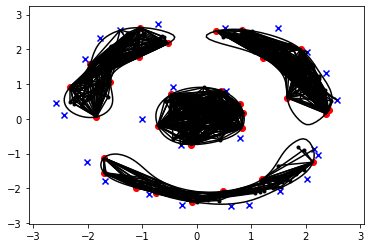

/home/gangmin/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:128: UserWarning: The following kwargs were not used by contour: 'lw'


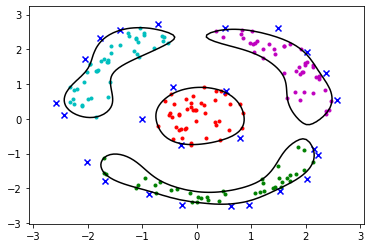

In [246]:
 # -*- coding: utf-8 -*-
# DO NOT CHANGE
import numpy as np
from itertools import product
from sklearn.svm import OneClassSVM
from scipy.sparse.csgraph import connected_components
import pandas as pd
import matplotlib.pyplot as plt

def get_adj_mat(X,svdd,num_cut):
    # 두 점 사이를 내분 한 후 내분점들이 decison 계산해서 0보다 큰지 작은지 계산
    # X: n*p input matrix
    # svdd: trained svdd model by sci-kit learn using X
    # num_cut: number of cutting points on line segment
    
    # matrix
    adj_mat = [[0 for _ in range(len(X))]for _ in range(len(X))]
    
    for sv in svdd.support_:
        for x_index,x in enumerate(X):
            inner_points=[]
            for i in range(1,num_cut): # num_cut으로 내분할 경우 n-1개의 점 생성
                m = i
                n = num_cut-i
                inner_points.append([(X[sv][0]*m+x[0]*n)/(m+n) ,(X[sv][1]*m+x[1]*n)/(m+n)])
            if np.sum(svdd.predict(inner_points)) == num_cut-1 :
                adj_mat[sv][x_index] = 1
    
    #######OUTPUT########
    # return adjacent matrix size of n*n (if two points are connected A_ij=1)
    return adj_mat


def cluster_label(A,bsv):
    # A: adjacent matrix size of n*n (if two points are connected A_ij=1)
    # bsv: index of bounded support vectors
    #######OUTPUT########
    # return cluster labels (if samples are bounded support vectors, label=-1)
    # cluster number starts from 0 and ends to the number of clusters-1 (0, 1, ..., C-1)
    # Hint: use scipy.sparse.csgraph.connected_components
    label = connected_components(np.array(A))
    for i,v in enumerate(label[1]):
        if i in bsv:
            label[1][i] = -1
    t = 0
    for i in np.unique(label[1]):
        if i != -1:
            label[1][label[1] == i] = t
            t+=1
    
    return label[1]

ring=pd.read_csv('https://drive.google.com/uc?export=download&id=1_ygiOJ-xEPVSIvj3OzYrXtYc0Gw_Wa3a')

num_cut=20
svdd=OneClassSVM(gamma=1, nu=0.2)

X = ring.values

#fit data
svdd.fit(X)

# adj_mat
adj_mat = get_adj_mat(X,svdd,num_cut)

# bounded_list
bounded = []
for i,c in zip(svdd.support_,svdd.dual_coef_[0]):
    if c == 1:
        bounded.append(i)

labels = cluster_label(adj_mat,bounded)




##########Plot1###################
# Get SVG figure (draw line between two connected points with scatter plots)
# draw decision boundary 
# mark differently for nsv, bsv, and free sv


xmin,xmax = X[:,0].min()-0.5, X[:,0].max()+0.5
ymin,ymax = X[:,1].min()-0.5, X[:,1].max()+0.5

X_,Y_ = np.meshgrid(np.linspace(xmin,xmax,100),np.linspace(ymin,ymax,100))
Z = np.c_[X_.ravel(),Y_.ravel()]
Z_pred=svdd.decision_function(Z)

plt.contour(X_,Y_,Z_pred.reshape(X_.shape),levels=[0],lw=2,colors='k')


plt.scatter(X[svdd.support_[svdd.dual_coef_[0]<1],0],X[svdd.support_[svdd.dual_coef_[0]<1],1],c='r')
plt.scatter(X[svdd.support_[svdd.dual_coef_[0]==1],0],X[svdd.support_[svdd.dual_coef_[0]==1],1],marker='x',c='b')
plt.scatter(X[np.isin(np.arange(200),svdd.support_)==False,0],X[np.isin(np.arange(200),svdd.support_)==False,1],marker='.',c='k')

        
sv_0 = np.intersect1d(svdd.support_[svdd.dual_coef_[0]<1],np.where(labels==0))
for i in sv_0:
    for j in range(len(adj_mat)):
        if adj_mat[i][j]==1:
            plt.plot([X[i][0],X[j][0]],[X[i][1],X[j][1]],c='k')

sv_1 = np.intersect1d(svdd.support_[svdd.dual_coef_[0]<1],np.where(labels==1))
for i in sv_1:
    for j in range(len(adj_mat)):
        if adj_mat[i][j]==1:
            plt.plot([X[i][0],X[j][0]],[X[i][1],X[j][1]],c='k')
            
sv_2 = np.intersect1d(svdd.support_[svdd.dual_coef_[0]<1],np.where(labels==2))
for i in sv_2:
    for j in range(len(adj_mat)):
        if adj_mat[i][j]==1:
            plt.plot([X[i][0],X[j][0]],[X[i][1],X[j][1]],c='k')
            
sv_3 = np.intersect1d(svdd.support_[svdd.dual_coef_[0]<1],np.where(labels==3))
for i in sv_3:
    for j in range(len(adj_mat)):
        if adj_mat[i][j]==1:
            plt.plot([X[i][0],X[j][0]],[X[i][1],X[j][1]],c='k')

plt.show()

##########Plot2###################
# Clsuter labeling result
# different clusters should be colored using different color
# outliers (bounded support vectors) are marked with 'x'
plt.contour(X_,Y_,Z_pred.reshape(X_.shape),levels=[0],lw=2,colors='k')

plt.scatter(X[labels==0,0],X[labels==0,1],marker='.',c='r')
plt.scatter(X[labels==1,0],X[labels==1,1],marker='.',c='g')
plt.scatter(X[labels==2,0],X[labels==2,1],marker='.',c='c')
plt.scatter(X[labels==3,0],X[labels==3,1],marker='.',c='m')

plt.scatter(X[svdd.support_[svdd.dual_coef_[0]==1],0],X[svdd.support_[svdd.dual_coef_[0]==1],1],marker='x',c='b')
plt.show()
